In [ ]:
import itertools
import mujoco
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy.spatial.transform import Rotation as R

In [45]:
class JumpSimulator:
    def __init__(self, horizontal_velocity, vertical_velocity, phi, theta, angular_velocity_x, angular_velocity_y):
        self.hv = horizontal_velocity
        self.vv = vertical_velocity
        self.p = phi
        self.t = theta
        self.avx = angular_velocity_x
        self.avy = angular_velocity_y

        self.num_steps = 400
        self.positions = []
        self.num_contacts = []
        self.saved_qpos = []
        self.angles_with_vertical = []  # ADDED: Track angles
        self.max_height_after = 0
        self.max_height_after_idx = None
        self.first_contact = None
        self.first_contact_end = None
        self.second_contact = None
        self.min_angle_between_contacts = None  # ADDED: Track minimum angle
        self.min_angle_step = None  # ADDED: Track step of minimum angle
        self.total_ke = None
        self.energy_threshold = 100

        self._setup_sim()

    def _setup_sim(self):
        half_rod_length = 0.9144
        xml = f"""
        <mujoco>
            <option gravity="0 0 -9.81"/>
            <worldbody>
                <camera name="sideview" pos="5 0 1" euler="0 90 90"/>
                <camera name="topview" pos="0 -0.5 5" euler="0 0 0"/>
                <geom name="ground" type="plane" size="2 2 0.1" pos="0 0 0" rgba="0 0.6 0 1" friction="1 0 0"/>
                <body name="rodd" pos="0 -0.5 1">
                    <freejoint/>
                    <geom name="rod" type="cylinder" pos="0 0 0" size="0.01 {half_rod_length}" rgba="1 1 1 1" solref="0.001 0" solimp="1 1 1 1 1" friction="1 0 0" density="1000"/>
                </body>
            </worldbody>
        </mujoco>
        """
        self.model = mujoco.MjModel.from_xml_string(xml)
        self.data = mujoco.MjData(self.model)

        self.data.qpos[0:3] = [0, -1, 0.01 + np.cos(self.t)*half_rod_length]
        self.data.qpos[3:7] = [
            np.cos(self.t/2) * np.cos(self.p/2),
            np.sin(self.t/2) * np.cos(self.p/2), 
            np.sin(self.t/2) * np.sin(self.p/2),
            np.cos(self.t/2) * np.sin(self.p/2) ]
        self.data.qvel[0:6] = [0, self.hv, self.vv, self.avx, self.avy, 0]

        self.rod_geom_id = mujoco.mj_name2id(self.model, mujoco.mjtObj.mjOBJ_GEOM, "rod")
    
    def calculate_energy(self):
        mass = self.model.body_mass[1]
        inertia = self.model.body_inertia[1]
        v_squared = self.hv**2 + self.vv**2
        translational_ke = 0.5 * mass * v_squared
        rotational_ke = 0.5 * (inertia[0] * self.avx**2 + inertia[1] * self.avy**2)
    
        self.total_ke = translational_ke + rotational_ke

    def run(self):
        self.calculate_energy()
        if self.total_ke < self.energy_threshold:
            for _ in range(self.num_steps):
                mujoco.mj_step(self.model, self.data)
                self.positions.append(self.data.xipos[1].copy())
                self.num_contacts.append(self.data.ncon)
                self.saved_qpos.append(self.data.qpos.copy())
                
                # ADDED: Calculate and store angle with vertical
                angle_vertical = self._calculate_angle_with_vertical()
                self.angles_with_vertical.append(angle_vertical)

            self.positions = np.array(self.positions)
            self.saved_qpos = np.array(self.saved_qpos)
            self.angles_with_vertical = np.array(self.angles_with_vertical)  # ADDED
            self._detect_contacts()
            self._compute_max_height()
            self._find_min_angle_between_contacts()  # ADDED
    
    # ADDED: Method to calculate angle with vertical
    def _calculate_angle_with_vertical(self):
        """Calculate the rod's angle with the vertical axis."""
        quat = self.data.qpos[3:7]  # [w, x, y, z] format in MuJoCo
        quat_xyzw = [quat[1], quat[2], quat[3], quat[0]]  # Convert to [x, y, z, w]
        
        rot_matrix = R.from_quat(quat_xyzw).as_matrix()
        rod_local_axis = np.array([0, 0, 1])  # Rod along Z-axis in local coordinates
        rod_world_axis = rot_matrix @ rod_local_axis
        
        vertical_axis = np.array([0, 0, 1])
        cos_angle = np.dot(rod_world_axis, vertical_axis)
        cos_angle = np.clip(cos_angle, -1, 1)
        angle_with_vertical = np.arccos(abs(cos_angle))
        
        return angle_with_vertical
    
    # ADDED: Method to find minimum angle between contacts
    def _find_min_angle_between_contacts(self):
        """Find the minimum angle with vertical between first and second contact."""
        self.min_angle_between_contacts = None
        self.min_angle_step = None
        
        if (self.first_contact_end is not None and 
            self.second_contact is not None and 
            len(self.angles_with_vertical) > 0):
            
            angles_between = self.angles_with_vertical[self.first_contact_end:self.second_contact]
            
            if len(angles_between) > 0:
                min_idx = np.argmin(angles_between)
                self.min_angle_between_contacts = angles_between[min_idx]
                self.min_angle_step = min_idx + self.first_contact_end
            
    def _detect_contacts(self):
        self.first_contact = None
        self.first_contact_end = None
        self.second_contact = None
        in_contact = False
        for i, n in enumerate(self.num_contacts):
            if n > 0 and not in_contact:
                if self.first_contact is None:
                    self.first_contact = i
                elif self.first_contact_end is not None and self.second_contact is None:
                    self.second_contact = i
                in_contact = True
            if n == 0 and in_contact:
                if self.first_contact_end is None:
                    self.first_contact_end = i
                in_contact = False

    def _compute_max_height(self):
        if self.first_contact_end is not None and self.second_contact is not None:
            z_between = self.positions[self.first_contact_end:self.second_contact, 2]
            if len(z_between) > 0:
                self.max_height_after = np.max(z_between)
                self.max_height_after_idx = np.argmax(z_between) + self.first_contact_end
        else:
            self.max_height_after = 0
            self.max_height_after_idx = None

    def get_max_height(self):
        return self.max_height_after
    
    # ADDED: Getter method for minimum angle
    def get_min_angle_between_contacts(self):
        """Get the minimum angle with vertical between first and second contact."""
        return self.min_angle_between_contacts

    def print_summary(self):
        if self.first_contact is not None and self.first_contact_end is not None:
            duration = self.first_contact_end - self.first_contact
            print(f"First collision lasts {duration} steps")
        elif self.first_contact is not None:
            print(f"First collision starts at step {self.first_contact} and lasts until the end of the simulation")
        else:
            print("No collision detected in the simulation")

        if self.max_height_after_idx is not None:
            print(f"Max height after collision: {self.max_height_after:.4f} m at step {self.max_height_after_idx}")
        else:
            print("No valid height found after collision.")
        
        # ADDED: Print minimum angle information
        if self.min_angle_between_contacts is not None:
            print(f"Minimum angle with vertical after collision: {np.degrees(self.min_angle_between_contacts):.2f}° at step {self.min_angle_step}")
        else:
            print("No minimum angle found after collision")

    def analyze_orientation_at_events(self):
        if self.first_contact is None or self.max_height_after_idx is None:
            return

        for step, label in [(self.first_contact, "contact"), (self.max_height_after_idx, "peak")]:
            quat = self.saved_qpos[step, 3:7]
            quat_xyzw = [quat[1], quat[2], quat[3], quat[0]]
            rot_matrix = R.from_quat(quat_xyzw).as_matrix()
            axis_yz = rot_matrix[1:, 2]
            angle_rad = np.arctan2(axis_yz[1], axis_yz[0])
            angle_deg = np.degrees(angle_rad)
            print(f"Angle at {label} (step {step}): {angle_deg:.2f} degrees")

    def summarize_parameters(self):
        print("Simulation Parameters:")
        print(f"  Horizontal Velocity: {self.hv:.2f} m/s")
        print(f"  Vertical Velocity: {self.vv:.2f} m/s")
        print(f"  Phi: {np.degrees(self.p):.2f} degrees")
        print(f"  Theta: {np.degrees(self.t):.2f} degrees")
        print(f"  Angular Velocity (X): {self.avx:.2f} rad/s")
        print(f"  Angular Velocity (Y): {self.avy:.2f} rad/s")
        print(f"  Initial Kinetic Energy: {self.total_ke: .4f} J")

    def animate_jump(self):
        frames_side = []
        frames_top = []
        num_frames = min(200, len(self.saved_qpos))

        # Use default renderer settings (same as your original)
        renderer = mujoco.Renderer(self.model)
        data_render = mujoco.MjData(self.model)
        
        for i in range(num_frames):
            data_render.qpos[:] = self.saved_qpos[i]
            mujoco.mj_forward(self.model, data_render)
            
            # Side view
            renderer.update_scene(data_render, camera="sideview")
            frames_side.append(renderer.render())
            
            # Top view
            renderer.update_scene(data_render, camera="topview")
            frames_top.append(renderer.render())

        # Create enhanced side-by-side animation (this is the only visual improvement)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
        
        im1 = ax1.imshow(frames_side[0])
        im2 = ax2.imshow(frames_top[0])
        
        ax1.axis('off')
        ax2.axis('off')
        ax1.set_title('Side View', fontsize=16, fontweight='bold')
        ax2.set_title('Top View', fontsize=16, fontweight='bold')

        def update_frame(i):
            im1.set_data(frames_side[i])
            im2.set_data(frames_top[i])
            return [im1, im2]

        ani = FuncAnimation(fig, update_frame, frames=num_frames, interval=50, blit=True)
        plt.tight_layout()
        plt.close(fig)
        display(HTML(ani.to_jshtml()))

In [46]:
def iterate(hv_min, hv_max, vv_min, vv_max, p_min, p_max, t_min, t_max, avx_min, avx_max, avy_min, avy_max):
    horizontal_velocity_range = np.arange(hv_min, hv_max, 0.1)
    vertical_velocity_range = np.arange(vv_min, vv_max, 0.1)
    phi_range = np.arange(np.deg2rad(p_min), np.deg2rad(p_max), np.deg2rad(1))
    theta_range = np.arange(np.deg2rad(t_min), np.deg2rad(t_max), np.deg2rad(1))
    angular_velocity_x_range = np.arange(avx_min, avx_max, 1)
    angular_velocity_y_range = np.arange(avy_min, avy_max, 1)

    jumps_over_energy = 0
    top_jump = 0
    jumps = 0
    for hv, vv, p, t, avx, avy in itertools.product(
            horizontal_velocity_range,
            vertical_velocity_range,
            phi_range,
            theta_range,
            angular_velocity_x_range,
            angular_velocity_y_range):
        sim = JumpSimulator(hv, vv, p, t, avx, avy)
        sim.run()

        if sim.total_ke > sim.energy_threshold:
            jumps_over_energy += 1
        
        max_height_after = sim.get_max_height()
        jumps+=1
        if max_height_after > top_jump:
            top_jump = max_height_after
            top_jump_hv = hv
            top_jump_vv = vv
            top_jump_p = p
            top_jump_t = t
            top_jump_avx = avx
            top_jump_avy = avy

    best_sim = JumpSimulator(top_jump_hv, top_jump_vv, top_jump_p, top_jump_t, top_jump_avx, top_jump_avy)
    best_sim.run()
    print(f"Total jumps over energy threshold: {jumps_over_energy}")
    print(f"Total jumps under energy threshold: {jumps - jumps_over_energy}")
    print(f"Top jump height: {top_jump:.4f} m")
    best_sim.summarize_parameters()
    best_sim.print_summary()
    best_sim.analyze_orientation_at_events()
    best_sim.animate_jump()

In [47]:
def flexible_graph(iv1, iv1_min, iv1_max, iv1_step, iv2, iv2_min, iv2_max, iv2_step, 
                   sv1, sv1_default, sv2, sv2_default, sv3, sv3_default, sv4, sv4_default):
    """
    Create line plots showing relationships between parameters and max jump height.
    
    Parameters:
    iv1, iv2: Independent variables to sweep ('hv', 'vv', 'p', 't', 'avx', 'avy')
    iv1_min, iv1_max, iv1_step: Range and step for first independent variable
    iv2_min, iv2_max, iv2_step: Range and step for second independent variable  
    sv1-sv4: Static variables to hold constant
    sv1_default-sv4_default: Values for static variables (angles should be in DEGREES)
    """
    # Set up the parameter names
    param_names = ['hv', 'vv', 'p', 't', 'avx', 'avy']
    static_vars = {sv1: sv1_default, sv2: sv2_default, sv3: sv3_default, sv4: sv4_default}

    # Create the ranges for the swept variables
    iv1_range = np.arange(iv1_min, iv1_max, iv1_step)
    iv2_range = np.arange(iv2_min, iv2_max, iv2_step)

    plt.figure(figsize=(12, 8))
    for iv2_value in iv2_range:
        max_heights = []
        iv1s = []
        for iv1_value in iv1_range:
            # Set up all parameters for this run
            params = static_vars.copy()
            params[iv1] = iv1_value
            params[iv2] = iv2_value

            # Convert angle parameters from degrees to radians for JumpSimulator
            sim_params = {}
            for param_name in ['hv', 'vv', 'p', 't', 'avx', 'avy']:
                value = params.get(param_name, 0)
                if param_name in ['p', 't']:
                    sim_params[param_name] = np.deg2rad(value)  # Convert to radians
                else:
                    sim_params[param_name] = value

            sim = JumpSimulator(
                sim_params['hv'],
                sim_params['vv'],
                sim_params['p'],
                sim_params['t'],
                sim_params['avx'],
                sim_params['avy']
            )

            sim.run()
            max_height_after = sim.get_max_height()
            iv1s.append(iv1_value)
            max_heights.append(max_height_after)

        # Make a nice label for the legend (values are already in degrees)
        if iv2 in ['p', 't']:  # Angle parameters
            label = f"{iv2}={iv2_value:.1f}°"
        else:
            label = f"{iv2}={iv2_value:.2f}"

        plt.plot(iv1s, max_heights, marker='o', markersize=3, label=label)

    # Format x-axis label
    if iv1 in ['p', 't']:
        plt.xlabel(f"{iv1} (deg)")
        # X-axis values are already in degrees, no conversion needed
    else:
        plt.xlabel(iv1)

    plt.ylabel('Max Jump Height (m)')
    plt.title(f'Max Jump Height vs {iv1} (for different {iv2})')
    plt.grid(True)
    plt.legend()
    
    # Show fixed parameters - positioned below the plot
    fixed_text = ""
    for param, value in static_vars.items():
        if param in ['p', 't']:
            # Values are already in degrees, no conversion needed
            fixed_text += f"Fixed {param}={value:.1f}°\n"
        else:
            fixed_text += f"Fixed {param}={value:.2f}\n"
    
    plt.gcf().text(
        0.12, 0.75,
        fixed_text.strip(),
        fontsize=10, va='bottom', ha='center',
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.8)
    )
    
    plt.subplots_adjust(bottom=0.15)
    plt.tight_layout()
    plt.show()


def flexible_heatmap(axis1, axis1_range, axis2, axis2_range, 
                     fixed1, fixed1_value, fixed2, fixed2_value, 
                     fixed3, fixed3_value, fixed4, fixed4_value):
    """
    Create a heatmap of max jump height for any two swept variables.
    
    Parameters:
    axis1, axis2: Names of variables to sweep ('hv', 'vv', 'p', 't', 'avx', 'avy')
    axis1_range, axis2_range: Arrays of values for those variables (angles in DEGREES)
    fixed1-fixed4: Names of fixed variables  
    fixed1_value-fixed4_value: Values for fixed variables (angles in DEGREES)
    """
    param_names = ['hv', 'vv', 'p', 't', 'avx', 'avy']
    
    # Input ranges are in degrees, use directly for display
    axis1_vals = axis1_range
    axis2_vals = axis2_range

    heights = np.zeros((len(axis2_vals), len(axis1_vals)))

    print(f"Computing heatmap: {len(axis2_vals)} x {len(axis1_vals)} = {len(axis2_vals) * len(axis1_vals)} simulations")
    
    for i, val2 in enumerate(axis2_vals):
        for j, val1 in enumerate(axis1_vals):
            params = {
                fixed1: fixed1_value, 
                fixed2: fixed2_value, 
                fixed3: fixed3_value, 
                fixed4: fixed4_value
            }
            params[axis1] = val1
            params[axis2] = val2
            
            # Convert angle parameters from degrees to radians for JumpSimulator
            sim_params = {}
            for param_name in ['hv', 'vv', 'p', 't', 'avx', 'avy']:
                value = params.get(param_name, 0)
                if param_name in ['p', 't']:
                    sim_params[param_name] = np.deg2rad(value)  # Convert to radians
                else:
                    sim_params[param_name] = value
            
            sim = JumpSimulator(
                sim_params['hv'],
                sim_params['vv'],
                sim_params['p'],
                sim_params['t'],
                sim_params['avx'],
                sim_params['avy']
            )
            sim.run()
            heights[i, j] = sim.get_max_height()
        
        # Progress indicator
        if (i + 1) % 5 == 0:
            print(f"Progress: {i + 1}/{len(axis2_vals)} rows completed")

    # For labeling (values are already in degrees)
    axis1_label = f"{axis1} (deg)" if axis1 in ['p', 't'] else axis1
    axis2_label = f"{axis2} (deg)" if axis2 in ['p', 't'] else axis2

    plt.figure(figsize=(12, 8))
    extent = [axis1_vals[0], axis1_vals[-1], axis2_vals[0], axis2_vals[-1]]
    cmap = plt.get_cmap('Reds').copy()
    cmap.set_bad(color='gray')
    masked_heights = np.ma.masked_invalid(heights)
    
    im = plt.imshow(masked_heights, extent=extent, origin='lower', aspect='auto', cmap=cmap)
    plt.colorbar(im, label='Max Jump Height (m)')
    plt.xlabel(axis1_label)
    plt.ylabel(axis2_label)
    
    # Create fixed parameters text (values are already in degrees)
    fixed_text = ""
    fixed_params = {fixed1: fixed1_value, fixed2: fixed2_value, fixed3: fixed3_value, fixed4: fixed4_value}
    for param, value in fixed_params.items():
        if param in ['p', 't']:
            fixed_text += f"{param}={value:.1f}°, "
        else:
            fixed_text += f"{param}={value:.2f}, "
    
    plt.title(f"Heatmap of Max Jump Height: {axis1} vs {axis2}\nFixed: {fixed_text.rstrip(', ')}")
    plt.grid(False)
    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print(f"\nHeatmap Summary:")
    print(f"Max height: {np.nanmax(heights):.4f} m")
    print(f"Min height: {np.nanmin(heights):.4f} m")
    print(f"Mean height: {np.nanmean(heights):.4f} m")
    
    # Find optimal parameters (values are in degrees)
    max_idx = np.unravel_index(np.nanargmax(heights), heights.shape)
    optimal_val1 = axis1_vals[max_idx[1]]
    optimal_val2 = axis2_vals[max_idx[0]]
    
    if axis1 in ['p', 't']:
        print(f"Optimal {axis1}: {optimal_val1:.1f}°")
    else:
        print(f"Optimal {axis1}: {optimal_val1:.2f}")
        
    if axis2 in ['p', 't']:
        print(f"Optimal {axis2}: {optimal_val2:.1f}°")
    else:
        print(f"Optimal {axis2}: {optimal_val2:.2f}")

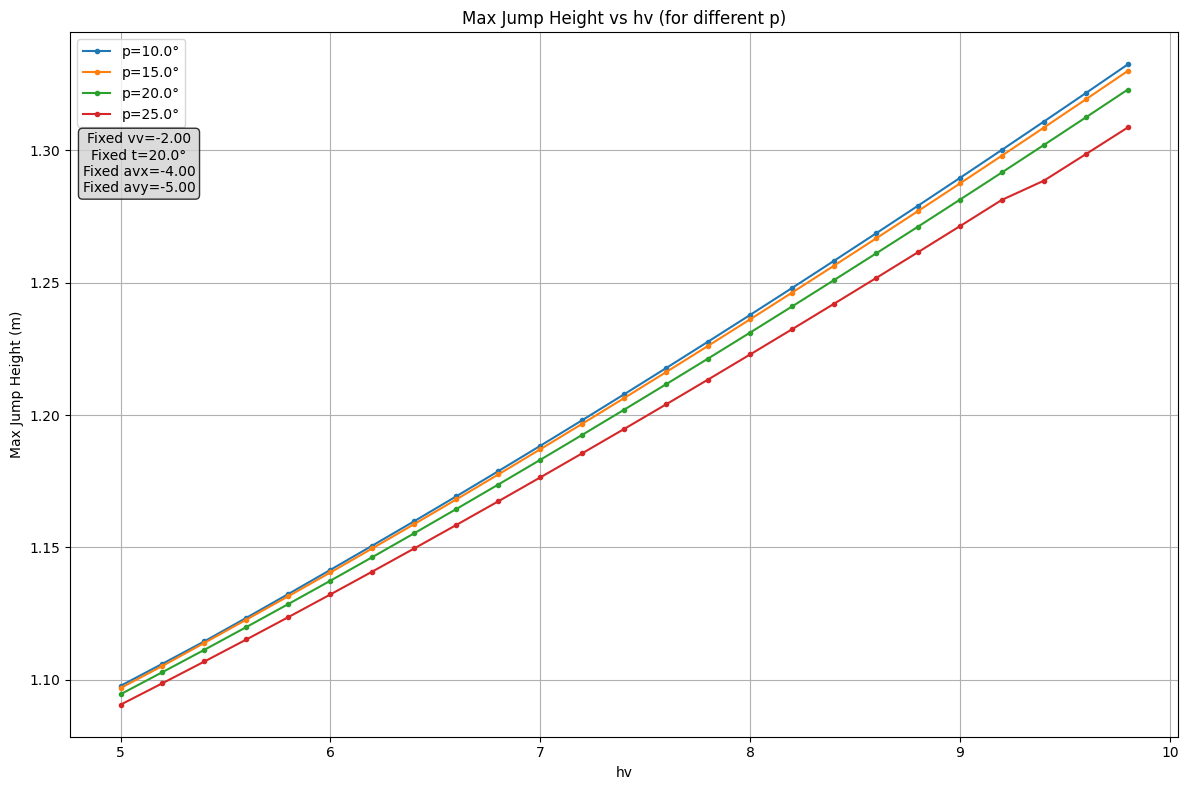

Computing heatmap: 20 x 20 = 400 simulations
Progress: 5/20 rows completed
Progress: 10/20 rows completed
Progress: 15/20 rows completed
Progress: 20/20 rows completed


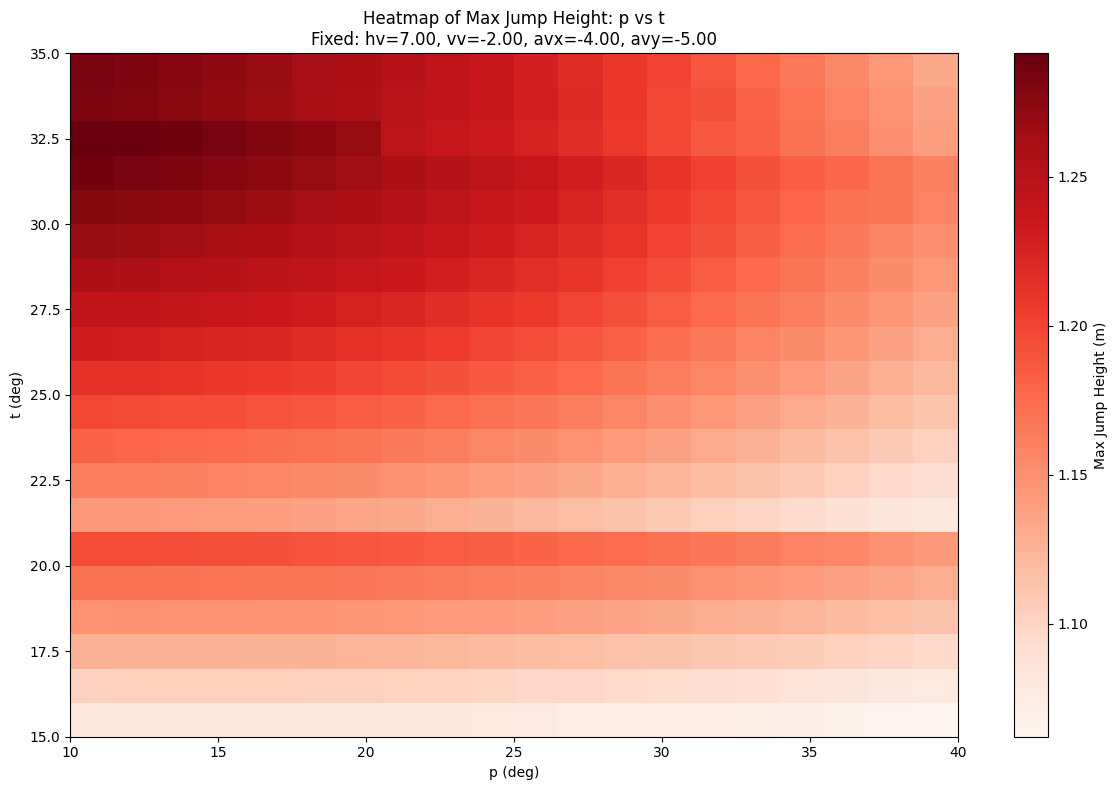


Heatmap Summary:
Max height: 1.2914 m
Min height: 1.0620 m
Mean height: 1.1728 m
Optimal p: 10.0°
Optimal t: 32.9°


In [48]:
#iterate(7.0, 7.01, -2, -1.99, 20, 20.1, 20, 20.1, -4.1, -4.0, -5.1, -5.0)
#horizontal_velocity, vertical_velocity, phi, theta, angular_velocity_x, angular_velocity_y    

# Line plot: Height vs horizontal velocity for different phi angles
flexible_graph('hv', 5, 10, 0.2, 'p', 10, 30, 5, 
               'vv', -2, 't', 20, 'avx', -4, 'avy', -5)

# Heatmap: Phi vs Theta optimization
flexible_heatmap('p', np.linspace(10, 40, 20), 't', np.linspace(15, 35, 20),
                 'hv', 7, 'vv', -2, 'avx', -4, 'avy', -5)
